In [3]:
%cd "D:\\python\\notebooks"
import os
import re
import pandas as pd
import numpy as np

D:\python\notebooks


In [4]:
cabinas_premium=[#Tenian escaleras cerca
"A34","A35","A32","A30","A31","A33","A28","A26","A27","A29",
"B98","B96","B94","B90","B88","B92","B84","B82","B78","B76","B73","B75","B77","B81","B79","B83","B85","B87","B89","B91","B93","B95","B97",
"C94","C96","C92","C90","C88","C86","C84","C82","C80","C148","C146","C144","C142","C140","C138","C136","C134","C132","C130","C127","C125","C123","C121","C119","C127","C125","C123","C89","C87","C85","C83",
"C81","C79","C77","C75","C73","C66","C64","C62","C46","C44","C42","C40","C38","C36","C34","C32","C30","C28","C26","C24","C22","C56","C58","C60","C104","C106","C108","C110","C101","C99","C97","C95","C59",
"C57","C39","C35","C37","C29","C31","C53","C51","C49","C23","C37","C8","C4","C2","C1","C3","C5","C7",
"D89","D81","D87","D85","D83","D77","D79","D75","D80","D76","D82","D78","D84","D86","D88","D62","D56","D66","D64","D61","D55","D34","D35",
"E105","E102","E99","E98","E89","E87","E85","E82","E63","E62","E66","E61","E27","E28","E30","E24","E22","E3","E5","E1","E7","E2","E201",
"F63","F59","F51","F50","F58","F24","F26","F28","F22","F18","F20","F29","F12","F15","F17","F31","F39",
"G20","G18","G19","G16","G10","G8","G6", 
]

In [5]:
def get_extra_data (row,cabinas_premium):
    cabin_to_number={
        "A":0,
        "B":1,
        "C":2,
        "D":3,
        "E":4,
        "F":5,
        "G":6,
        "T":7
    }
    is_miss=0
    is_mrs=0
    is_mr=0
    is_master=0
    is_other=0
    is_nobility=0
    is_rev=0
    is_dr=0
    is_french=0
    is_soldier=0
    is_captain=0
    first_10k=0
    is_prepaid=0
    is_naviera=0
    is_wc=0
    is_agent_a=0
    is_agent_ca=0
    is_agent_sc=0
    is_special=0
    super_cabin=0
    is_Southampton=0
    is_Queenstown=0
    is_Cherbourg=0
    ########NAME
    if "Rev." in row["Name"]:
        is_rev=1
        is_mr=1
        
    elif "Dr." in row["Name"]:
        is_dr=1
        if "female" in row["Sex"]:
            is_miss=1
        elif "male" in row["Sex"]:
            is_mr=1
        else:
            raise Exception("Algo salio mal...")
    elif "Mme." in row["Name"]:
        is_french=1
        is_mrs=1
    elif "Mlle." in row["Name"]:
        is_french=1
        is_miss=1
    elif "Jonkheer." in row["Name"]:
        is_mr=1
        is_french=1
    elif "Capt." in row["Name"]:
        is_mr=1
        is_captain=1
    elif "Col." in row["Name"] or "Major." in row["Name"]:
        is_soldier=1
        is_mr=1
    elif "Lady." in row["Name"] or "Countess." in row["Name"] or "Dona." in row["Name"]:
        is_mrs=1
        is_nobility =1
    elif "Sir." in row["Name"]:
        is_mr=1
        is_nobility=1
    elif "Miss." in row["Name"] or "Ms." in row["Name"]:#solteras
        is_miss=1
    elif "Mr." in row["Name"] or "Don." in row["Name"]:#Hombre Adulto
        is_mr=1
    elif "Mrs." in row["Name"]:#Casados Mujer
        
        is_mrs=1
    elif "Master." in row["Name"]:#Jovenes
        is_master=1
    else:
        print(row["Name"])
        raise Exception("Tiene un titulo raro")
        is_other=1
    ####### Ticket         
    if "PP" in row["Ticket"] or "P.P" in row["Ticket"]:
        is_prepaid =1
    elif "LINE" in row["Ticket"]:
        is_naviera =1
    elif "CA" in row["Ticket"] or "C.A" in row["Ticket"] :
        is_agent_ca = 1
    elif (("A"  in row["Ticket"]  and "." in row["Ticket"]) or "A/" in row["Ticket"]):   
        is_agent_a = 1    
    elif ("SC" in row["Ticket"] or "S.C" in row["Ticket"] ):
        is_agent_sc=1
    elif("W/C" in row["Ticket"] or "W./C" in row["Ticket"]):
        is_wc =1
    elif("SP" in row["Ticket"]  or "S.P" in   row["Ticket"]):
        is_special =1
    if is_naviera==0:   
        try:
            no_ticket=int(row["Ticket"])
        except:
            
            no_ticket=int(row["Ticket"].split(" ")[-1])
    else:
        no_ticket=99_999
        
    if no_ticket <= 10_000:
        first_10k=1
    ###Embarked
    if row["Embarked"] == "Q":
        is_Queenstown =1
    elif row["Embarked"] == "C":
        is_Cherbourg =1
    elif row["Embarked"] == "S":
        is_Southampton = 1
    #Cabin
    if not pd.isna(row["Cabin"]):
        
        if row["Cabin"] in cabinas_premium:
            super_cabin=1
        level=cabin_to_number[row["Cabin"][0]]
    else:
        level=3
    return pd.Series([is_miss,is_mr,is_mrs,is_master,is_nobility,is_rev,is_dr,is_french,is_soldier,is_captain,is_prepaid,is_naviera,is_agent_ca,is_agent_a,is_agent_sc,is_wc,is_special,first_10k,
                      super_cabin,is_Queenstown,is_Cherbourg,is_Southampton,level])

In [6]:
def correct_age(row,mean_ladies,mean_married,mean_mr):
    if pd.isna(row["Age"]):
        if row["is_master"]:
            return 6
        elif row["is_miss"]:
            return mean_ladies
        elif row["is_mrs"]:
            return mean_married
        else:
            return mean_mr
            
    else:
        return row["Age"]
    

In [7]:

df = pd.read_csv("./DATASETS/titanic/train.csv",sep=",")
df=df.drop(columns=['PassengerId'])
df[['is_miss',"is_mr","is_mrs","is_master","is_nobility","is_rev","is_dr","is_french","is_soldier","is_captain","is_prepaid","is_naviera",
   "is_agent_ca","is_agent_a","is_agent_sc","is_wc","is_special","first_10k","super_cabin","is_Queenstown","is_Cherbourg","is_Southampton","level"]] = df.apply(get_extra_data, axis=1,result_type="expand",cabinas_premium=cabinas_premium)

just_ladys=df[df['is_miss'] == 1]
just_married_ladies=df[df['is_mrs'] == 1]
just_mr= df[df['is_mr'] == 1]
mean_age_ladies = just_ladys["Age"].mean()
mean_age_mr=just_mr["Age"].mean()
mean_age_married_ladies=just_married_ladies["Age"].mean()
print(mean_age_ladies,mean_age_married_ladies,mean_age_mr)
df["Age"]= df.apply(correct_age, axis=1,mean_ladies=mean_age_ladies,mean_married=mean_age_married_ladies,mean_mr=mean_age_mr)

df.tail()

22.026666666666667 35.873873873873876 32.98441247002398


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,...,is_agent_a,is_agent_sc,is_wc,is_special,first_10k,super_cabin,is_Queenstown,is_Cherbourg,is_Southampton,level
886,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.00,NaN,...,0,0,0,0,0,0,0,0,1,3
887,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.00,B42,...,0,0,0,0,0,0,0,0,1,1
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,22.026667,1,2,W./C. 6607,23.45,NaN,...,0,0,1,0,1,0,0,0,1,3
889,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.00,C148,...,0,0,0,0,0,1,0,1,0,2
890,0,3,"Dooley, Mr. Patrick",male,32.000000,0,0,370376,7.75,NaN,...,0,0,0,0,0,0,1,0,0,3


In [8]:
special_tickets=set()
for ticket in df["Ticket"]:
    try:
        aux=int(ticket)
    except:
        special_tickets.add(ticket)
print(special_tickets)

{'CA. 2314', 'PC 17558', 'PC 17597', 'PC 17608', 'STON/O 2. 3101285', 'A/5 3902', 'S.W./PP 752', 'C 7077', 'A/4. 34244', 'C 7075', 'PC 17758', 'PC 17318', 'W./C. 6609', 'SC/AH 3085', 'A/5. 851', 'SO/C 14885', 'SOTON/O.Q. 3101310', 'SOTON/OQ 3101316', 'PC 17593', 'SC/AH 29037', 'PC 17476', 'C.A. 17248', 'C 7076', 'PC 17482', 'A.5. 11206', 'STON/O 2. 3101289', 'W./C. 14258', 'A/5 2817', 'PC 17760', 'A/5 21174', 'C.A. 29566', 'A/5. 13032', 'Fa 265302', 'PC 17612', 'PC 17755', 'SOTON/OQ 3101317', 'C.A. 2315', 'A/5. 3336', 'S.O.P. 1166', 'CA. 2343', 'SOTON/OQ 392086', 'A/4. 39886', 'A/5. 2151', 'A/5 3594', 'A/5. 10482', 'C.A./SOTON 34068', 'STON/O 2. 3101292', 'SOTON/O.Q. 392078', 'A/5 3536', 'SOTON/O.Q. 3101306', 'A/4 45380', 'PC 17761', 'A4. 54510', 'SC/PARIS 2131', 'STON/O2. 3101290', 'PC 17756', 'A/4 48871', 'W./C. 14263', 'A/5 21171', 'PC 17585', 'STON/O 2. 3101273', 'W/C 14208', 'A/5 21172', 'PC 17759', 'PC 17754', 'C 17369', 'C.A. 2673', 'PC 17603', 'PC 17757', 'C.A. 31026', 'STON/O 

In [9]:
df=df.drop(columns=['Name',"Sex","Ticket","Cabin","Embarked","is_captain"])
print(df.columns)

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'is_miss',
       'is_mr', 'is_mrs', 'is_master', 'is_nobility', 'is_rev', 'is_dr',
       'is_french', 'is_soldier', 'is_prepaid', 'is_naviera', 'is_agent_ca',
       'is_agent_a', 'is_agent_sc', 'is_wc', 'is_special', 'first_10k',
       'super_cabin', 'is_Queenstown', 'is_Cherbourg', 'is_Southampton',
       'level'],
      dtype='str')


In [10]:
#conteo = (df['is_special'] ==1  ).sum()
#filtered_df = df[df['is_other'] == 1]
#print(conteo)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 28 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Survived        891 non-null    int64  
 1   Pclass          891 non-null    int64  
 2   Age             891 non-null    float64
 3   SibSp           891 non-null    int64  
 4   Parch           891 non-null    int64  
 5   Fare            891 non-null    float64
 6   is_miss         891 non-null    int64  
 7   is_mr           891 non-null    int64  
 8   is_mrs          891 non-null    int64  
 9   is_master       891 non-null    int64  
 10  is_nobility     891 non-null    int64  
 11  is_rev          891 non-null    int64  
 12  is_dr           891 non-null    int64  
 13  is_french       891 non-null    int64  
 14  is_soldier      891 non-null    int64  
 15  is_prepaid      891 non-null    int64  
 16  is_naviera      891 non-null    int64  
 17  is_agent_ca     891 non-null    int64  
 18  i

In [12]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare,is_miss,is_mr,is_mrs,is_master,...,is_agent_a,is_agent_sc,is_wc,is_special,first_10k,super_cabin,is_Queenstown,is_Cherbourg,is_Southampton,level
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,...,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.843003,0.523008,0.381594,32.204208,0.208754,0.602694,0.143659,0.044893,...,0.035915,0.015713,0.011223,0.001122,0.195286,0.052750,0.086420,0.188552,0.722783,2.860831
std,0.486592,0.836071,13.271043,1.102743,0.806057,49.693429,0.406647,0.489615,0.350940,0.207186,...,0.186182,0.124431,0.105403,0.033501,0.396644,0.223659,0.281141,0.391372,0.447876,0.750088
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
50%,0.000000,3.000000,30.000000,0.000000,0.000000,14.454200,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000
75%,1.000000,3.000000,35.873874,1.000000,0.000000,31.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


In [13]:
import matplotlib.pyplot as plt

In [14]:
key = "Age"
Q1 = df[key].quantile(0.25)
Q3 = df[key].quantile(0.75)

IQR = Q3 - Q1

inferior = Q1 - 1.5 * IQR
superior = Q3 + 1.5 * IQR

outliers = df[(df[key] < inferior) | (df[key] > superior)]

print(len(outliers))

49


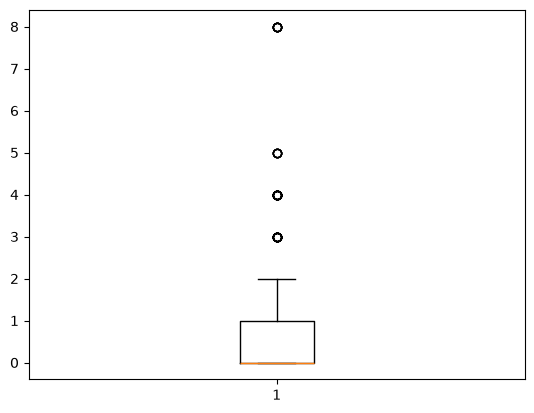

In [15]:
plt.boxplot(df["SibSp"])
plt.show()

In [16]:
###DATA a predecir
y = df["Survived"]
X = df.drop("Survived", axis=1)


In [17]:
from sklearn.model_selection import train_test_split

In [18]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=67
)



In [19]:
from sklearn.preprocessing import RobustScaler, OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
scaler = RobustScaler()
ct = ColumnTransformer(
    transformers=[
        ('scale', RobustScaler(), ['Age', 'SibSp','Parch',"Fare"]),
        ('encode', OneHotEncoder(), ['level'])
    ],
    remainder='passthrough' # Keeps any columns not specified
)
X_train = ct.fit_transform(X_train)
#X_train = ct.fit_transform(X)
#y_train= y
X_test = ct.transform(X_test)


In [20]:
print(np.mean(X_train[:, :4], axis=0)) 
print(np.max(X_train[:, :4], axis=0))
print(np.min(X_train[:, :4], axis=0))
print(np.median(X_train[:, :4], axis=0))
print(ct.get_feature_names_out())

[-0.0868034   0.56460674  0.37640449  0.73419996]
[ 3.53861968  8.          6.         22.00544335]
[-2.20838755  0.          0.         -0.63999213]
[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 -3.92481186e-17]
['scale__Age' 'scale__SibSp' 'scale__Parch' 'scale__Fare'
 'encode__level_0' 'encode__level_1' 'encode__level_2' 'encode__level_3'
 'encode__level_4' 'encode__level_5' 'encode__level_6' 'encode__level_7'
 'remainder__Pclass' 'remainder__is_miss' 'remainder__is_mr'
 'remainder__is_mrs' 'remainder__is_master' 'remainder__is_nobility'
 'remainder__is_rev' 'remainder__is_dr' 'remainder__is_french'
 'remainder__is_soldier' 'remainder__is_prepaid' 'remainder__is_naviera'
 'remainder__is_agent_ca' 'remainder__is_agent_a' 'remainder__is_agent_sc'
 'remainder__is_wc' 'remainder__is_special' 'remainder__first_10k'
 'remainder__super_cabin' 'remainder__is_Queenstown'
 'remainder__is_Cherbourg' 'remainder__is_Southampton']


In [21]:
print(X_train.shape)
print(y_train.shape)

print(np.max(X_train), np.min(X_train))
print(np.max(y_train), np.min(y_train))

print(X_train[:5])
print(y_train[0])

(712, 34)
(712,)
22.00544334654205 -2.2083875500962886
1 0
[[ 1.15546765  0.          0.         -0.24218362  0.          0.
   0.          1.          0.          0.          0.          0.
   3.          0.          1.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          1.        ]
 [-0.57773383  0.          0.         -0.30627499  0.          0.
   0.          1.          0.          0.          0.          0.
   3.          1.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   1.          0.          0.          0.          0.          1.
   0.          0.          0.          1.        ]
 [-0.14443346  0.          0.         -0.2208213   0.          0.
   0.          1.          0.          0.          0.          0.
   3.          0.          1.          0.      

In [22]:
for i in range(X_train.shape[1]):
    col_max = np.max(X_train[:, i])
    col_min = np.min(X_train[:, i])
    
    print(i, "min:", col_min, "max:", col_max)

0 min: -2.2083875500962886 max: 3.5386196845885594
1 min: 0.0 max: 8.0
2 min: 0.0 max: 6.0
3 min: -0.6399921322315512 max: 22.00544334654205
4 min: 0.0 max: 1.0
5 min: 0.0 max: 1.0
6 min: 0.0 max: 1.0
7 min: 0.0 max: 1.0
8 min: 0.0 max: 1.0
9 min: 0.0 max: 1.0
10 min: 0.0 max: 1.0
11 min: 0.0 max: 1.0
12 min: 1.0 max: 3.0
13 min: 0.0 max: 1.0
14 min: 0.0 max: 1.0
15 min: 0.0 max: 1.0
16 min: 0.0 max: 1.0
17 min: 0.0 max: 1.0
18 min: 0.0 max: 1.0
19 min: 0.0 max: 1.0
20 min: 0.0 max: 1.0
21 min: 0.0 max: 1.0
22 min: 0.0 max: 1.0
23 min: 0.0 max: 1.0
24 min: 0.0 max: 1.0
25 min: 0.0 max: 1.0
26 min: 0.0 max: 1.0
27 min: 0.0 max: 1.0
28 min: 0.0 max: 1.0
29 min: 0.0 max: 1.0
30 min: 0.0 max: 1.0
31 min: 0.0 max: 1.0
32 min: 0.0 max: 1.0
33 min: 0.0 max: 1.0


In [23]:
i=0
for vector in X_test:
    i+=1
print(y_train[:5])


873    0
649    1
713    0
135    0
639    0
Name: Survived, dtype: int64


In [24]:
class MyKNNModel():
    def fit(this,X_train,y_train,k):
        this.X_train=X_train
        this.y_train=y_train.reset_index(drop=True)
        this.k=k
    def predict(this,X_test):
        y_predict=[]
        for vector in X_test:
            distancias=np.sum(np.abs((this.X_train-vector)), axis=1)
            indices = np.arange(distancias.shape[0])
            distancias= np.c_[indices,distancias]
            sorted_distance = distancias[distancias[:, 1].argsort()]
            knn_values=[]
            #print(len(y_train))
            
            for row in sorted_distance[:this.k]:
                indice=int(row[0])
                resultado=this.y_train[indice]
                
                knn_values.append(resultado)
            vals, counts = np.unique(knn_values, return_counts=True)

            # Find all values that match the maximum frequency count
            all_modes = vals[np.argwhere(counts == np.max(counts)).flatten()]
            
            if len(all_modes) != 1:
                for resultado in knn_values:
                    if resultado in all_modes:
                        y_predict.append(int(resultado))
                        break
                
            else:
                y_predict.append(int(all_modes[0]))
            
        return y_predict

In [25]:

model = MyKNNModel()
model.fit(X_train,y_train,15)
y_pred=model.predict(X_test)
print(model.)
    
        
    
        
    

0      0
1      1
2      0
3      0
4      0
      ..
707    0
708    1
709    0
710    1
711    1
Name: Survived, Length: 712, dtype: int64
[0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0]


In [26]:
y_test_aux=y_test.T
print(y_pred)
y_test_list= list(y_test_aux)
print(y_test_list)

[0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0]
[0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0,

In [27]:

VP=0
VN=0
FP=0
FN=0

for index, valor in enumerate(y_pred):
   
    if valor== y_test_list[index]:
        if valor==1:
            VP+=1
        else:
            VN+=1
    else:
        if valor ==1:
            FP+=1
        else:
            FN+=1
m_confusion= np.array([[VN,FP],
                       [FN,VP]]) 
accuarcy= (VP+VN)/(VP+VN+FP+FN)
print(accuarcy)
 
    

0.7821229050279329


In [28]:
accuarcy= (VP+VN)/(VP+VN+FP+FN)
print(accuarcy)#¿Qué porcentaje de todas las predicciones fueron correctas?
precision= VP/(VP+FP)
print(precision)#De todo lo que el modelo dijo que era positivo, ¿cuánto realmente era positivo?
recall= VP/(VP+FN)
print(recall)#De todos los positivos reales, ¿cuántos encontró el modelo?
f1_score=2*((precision*recall)/(precision+recall))
print(f1_score)
specificity=VN/(VN+FP)#De todos los positivos reales, ¿cuántos encontró el modelo?
print(specificity)

0.7821229050279329
0.7681159420289855
0.6973684210526315
0.7310344827586206
0.8446601941747572


In [27]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [28]:
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(f1_score(y_test,y_pred))


[[91 12]
 [23 53]]
0.8044692737430168
0.8153846153846154
0.6973684210526315
0.75177304964539


In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       103
           1       0.82      0.70      0.75        76

    accuracy                           0.80       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.80      0.80       179



In [30]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(
    n_neighbors=7,
    metric="manhattan",
    weights="uniform"
)

In [31]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(
    n_neighbors=9,
    metric="manhattan",
    weights="uniform"
)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       103
           1       0.82      0.70      0.75        76

    accuracy                           0.80       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.80      0.80       179



In [32]:
#para el ejercicio de kaggle utilizare mi modelo...
df_ori = pd.read_csv("./DATASETS/titanic/test.csv",sep=",")
df=df_ori.drop(columns=['PassengerId'])
df[['is_miss',"is_mr","is_mrs","is_master","is_nobility","is_rev","is_dr","is_french","is_soldier","is_captain","is_prepaid","is_naviera",
   "is_agent_ca","is_agent_a","is_agent_sc","is_wc","is_special","first_10k","super_cabin","is_Queenstown","is_Cherbourg","is_Southampton","level"]] = df.apply(get_extra_data, axis=1,result_type="expand",cabinas_premium=cabinas_premium)

just_ladys=df[df['is_miss'] == 1]
just_married_ladies=df[df['is_mrs'] == 1]
just_mr= df[df['is_mr'] == 1]
mean_age_ladies = just_ladys["Age"].mean()
mean_age_mr=just_mr["Age"].mean()
mean_age_married_ladies=just_married_ladies["Age"].mean()
print(mean_age_ladies,mean_age_married_ladies,mean_age_mr)
df["Age"]= df.apply(correct_age, axis=1,mean_ladies=mean_age_ladies,mean_married=mean_age_married_ladies,mean_mr=mean_age_mr)

df.tail()


21.774843750000002 38.904761904761905 32.340425531914896


,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,...,is_agent_a,is_agent_sc,is_wc,is_special,first_10k,super_cabin,is_Queenstown,is_Cherbourg,is_Southampton,level
413,3,"Spector, Mr. Woolf",male,32.340426,0,0,A.5. 3236,8.0500,NaN,S,...,1,0,0,0,1,0,0,0,1,3
414,1,"Oliva y Ocana, Dona. Fermina",female,39.000000,0,0,PC 17758,108.9000,C105,C,...,0,0,0,0,0,0,0,1,0,2
415,3,"Saether, Mr. Simon Sivertsen",male,38.500000,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,...,0,0,0,0,0,0,0,0,1,3
416,3,"Ware, Mr. Frederick",male,32.340426,0,0,359309,8.0500,NaN,S,...,0,0,0,0,0,0,0,0,1,3
417,3,"Peter, Master. Michael J",male,6.000000,1,1,2668,22.3583,NaN,C,...,0,0,0,0,1,0,0,1,0,3


In [33]:
df=df.drop(columns=['Name',"Sex","Ticket","Cabin","Embarked","is_captain"])
print(df.columns)
####Drop carcteristics n-1
#df=df.drop(columns=["is_mr","is_Southampton"])


X = ct.transform(df)
y_pred=model.predict(X)


print(y_pred)


Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'is_miss', 'is_mr', 'is_mrs',
       'is_master', 'is_nobility', 'is_rev', 'is_dr', 'is_french',
       'is_soldier', 'is_prepaid', 'is_naviera', 'is_agent_ca', 'is_agent_a',
       'is_agent_sc', 'is_wc', 'is_special', 'first_10k', 'super_cabin',
       'is_Queenstown', 'is_Cherbourg', 'is_Southampton', 'level'],
      dtype='str')
[0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0,

In [34]:
X = ct.transform(df)
y_pred=model.predict(X)


print(y_pred)


[0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 

In [35]:
with open("./respuesta.csv","w") as fo:
    fo.write("PassengerId,Survived\n")
    for index,id_p in enumerate(df_ori['PassengerId']):
        fo.write(f"{id_p},{y_pred[index]}\n")
    